# CLV Modeling: BG/NBD + Gamma-Gamma

This notebook fits the probabilistic CLV model on customer transaction history:

1. **BG/NBD model** — predicts future purchase frequency per customer
2. **Gamma-Gamma model** — predicts average transaction value per customer
3. **CLV = predicted purchases × expected spend** over 12-month horizon

**Key assumption:** One-time buyers (~69.2%) are NOT excluded — BG/NBD natively models them as having dropped out after their first purchase, which is the correct answer for that cohort.

**Outputs:**
- `models/bgnbd_model.pkl` — fitted BG/NBD model
- `models/gg_model.pkl` — fitted Gamma-Gamma model
- `data/processed/clv_scored.csv` — per-customer CLV predictions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.plotting import (
    plot_frequency_recency_matrix,
    plot_probability_alive_matrix,
    plot_period_transactions,
)
from scipy.stats import pearsonr

# Paths
DATA_PATH   = "../data/raw/clv_data.csv"
SCORED_PATH = "../data/processed/clv_scored.csv"
BGNBD_PATH  = "../models/bgnbd_model.pkl"
GG_PATH     = "../models/gg_model.pkl"

# CLV horizon
CLV_MONTHS = 12
CLV_DAYS   = 365

print("Libraries loaded.")

Libraries loaded.


## 1. Load Data

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} customers × {df.shape[1]} features")
print(f"\nBG/NBD core inputs:")
print(df[['frequency', 'recency', 'T', 'monetary_value']].describe().round(2))

Loaded 52,507 customers × 24 features

BG/NBD core inputs:
       frequency   recency         T  monetary_value
count   52507.00  52507.00  52507.00        52507.00
mean        0.42    165.32    723.39           86.55
std         0.73    346.13    532.09           91.82
min         0.00      0.00      8.00            0.02
25%         0.00      0.00    275.00           30.00
50%         0.00      0.00    615.00           58.00
75%         1.00    132.00   1092.00          109.95
max         3.00   2164.00   2276.00         1264.60


One-time buyers (frequency=0): 36,354 (69.2%)
Repeat buyers   (frequency≥1): 16,153 (30.8%)


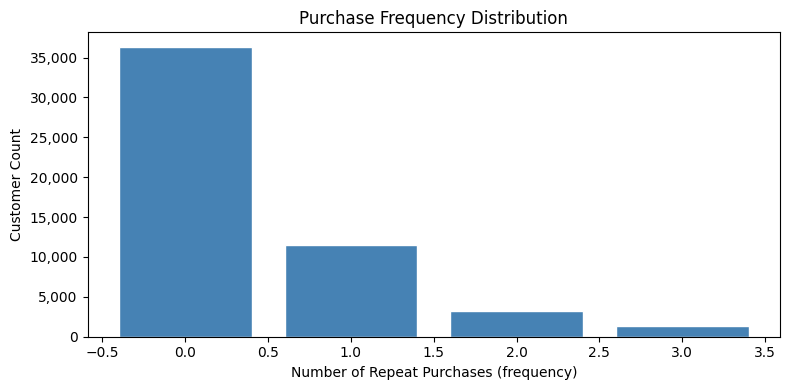

In [3]:
# One-time buyer breakdown
one_time = (df['frequency'] == 0).sum()
repeat   = (df['frequency'] >= 1).sum()
print(f"One-time buyers (frequency=0): {one_time:,} ({one_time/len(df):.1%})")
print(f"Repeat buyers   (frequency≥1): {repeat:,} ({repeat/len(df):.1%})")

# Frequency distribution
fig, ax = plt.subplots(figsize=(8, 4))
freq_counts = df['frequency'].value_counts().sort_index().head(15)
ax.bar(freq_counts.index, freq_counts.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Number of Repeat Purchases (frequency)')
ax.set_ylabel('Customer Count')
ax.set_title('Purchase Frequency Distribution')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 2. Fit BG/NBD Model

The **Beta-Geometric / Negative Binomial Distribution (BG/NBD)** model:
- Models each customer's purchase rate as Poisson with gamma-distributed heterogeneity
- Models dropout probability as beta-geometric process
- Outputs: probability a customer is still alive (`p_alive`) + predicted future transactions

In [ ]:
# Fit BG/NBD model
bgf = BetaGeoFitter(penalizer_coef=0.01) # Add small regularization to prevent overfitting
bgf.fit(
    df['frequency'],
    df['recency'],
    df['T'],
    verbose=True
)

print("\n=== BG/NBD Model Summary ===")
print(bgf.summary)

Optimization terminated successfully.
         Current function value: 0.313354
         Iterations: 27
         Function evaluations: 29
         Gradient evaluations: 29

=== BG/NBD Model Summary ===
              coef   se(coef)  lower 95% bound  upper 95% bound
r         0.754868   0.013730         0.727958         0.781779
alpha  1058.146043  24.593641      1009.942507      1106.349580
a         0.097240   0.010732         0.076204         0.118275
b         0.278227   0.023703         0.231769         0.324685


In [7]:
print(df['frequency'].describe())
print(df['T'].describe())
print(df['recency'].describe())

count    52507.000000
mean         0.422896
std          0.726733
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          3.000000
Name: frequency, dtype: float64
count    52507.000000
mean       723.394290
std        532.090185
min          8.000000
25%        275.000000
50%        615.000000
75%       1092.000000
max       2276.000000
Name: T, dtype: float64
count    52507.000000
mean       165.316301
std        346.131637
min          0.000000
25%          0.000000
50%          0.000000
75%        132.000000
max       2164.000000
Name: recency, dtype: float64


In [21]:
print(df['actual_holdout_transactions'].value_counts(normalize=True))
# What % of customers have 0 transactions in holdout?

actual_holdout_transactions
0    0.877140
1    0.109585
2    0.011884
3    0.001390
Name: proportion, dtype: float64


count    52507.000000
mean         0.912787
std          0.151104
min          0.284187
25%          0.892364
50%          1.000000
75%          1.000000
max          1.000000
Name: p_alive, dtype: float64


<Axes: >

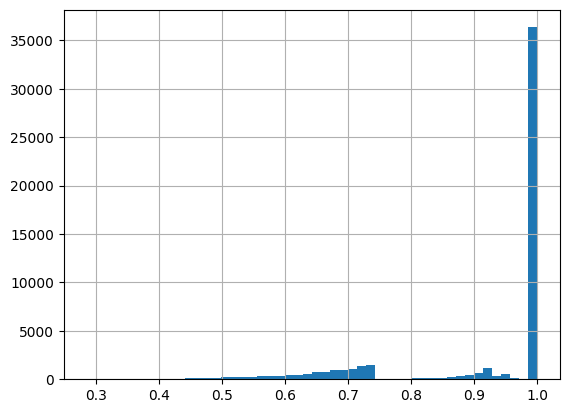

In [20]:
print(df['p_alive'].describe())
import matplotlib.pyplot as plt
df['p_alive'].hist(bins=50)

In [22]:
repeat_buyers = df[df['frequency'] > 0]
one_time = df[df['frequency'] == 0]

print(repeat_buyers[['total_sessions','cart_events','days_since_last_visit']].mean())
print(one_time[['total_sessions','cart_events','days_since_last_visit']].mean())

total_sessions             3.451805
cart_events                6.561072
days_since_last_visit    407.952021
dtype: float64
total_sessions             1.451395
cart_events                2.748033
days_since_last_visit    623.848380
dtype: float64


In [6]:
# Sanity check: all params should be positive
params = bgf.params_
for name, val in params.items():
    assert val > 0, f"BG/NBD param '{name}' = {val:.4f} — must be positive"
print("✓ All BG/NBD parameters are positive")
print(f"  r={params['r']:.4f}, α={params['alpha']:.4f}, a={params['a']:.4f}, b={params['b']:.4f}")

✓ All BG/NBD parameters are positive
  r=0.7549, α=1058.1460, a=0.0972, b=0.2782


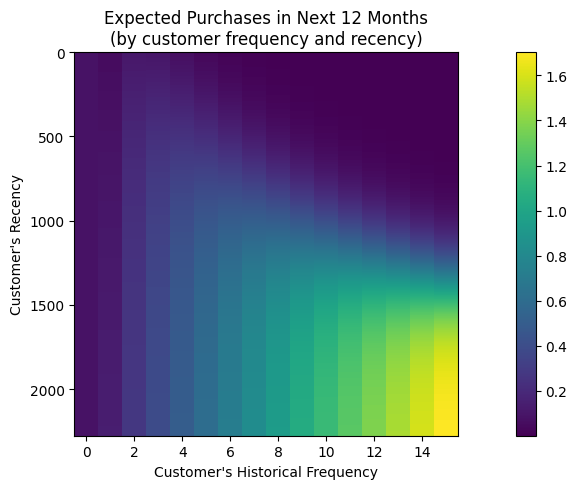

In [8]:
# Frequency-Recency matrix: expected purchases in next 12 months
fig = plt.figure(figsize=(12, 5))
plot_frequency_recency_matrix(bgf, T=CLV_DAYS, max_frequency=15)
plt.title('Expected Purchases in Next 12 Months\n(by customer frequency and recency)')
plt.tight_layout()
plt.show()

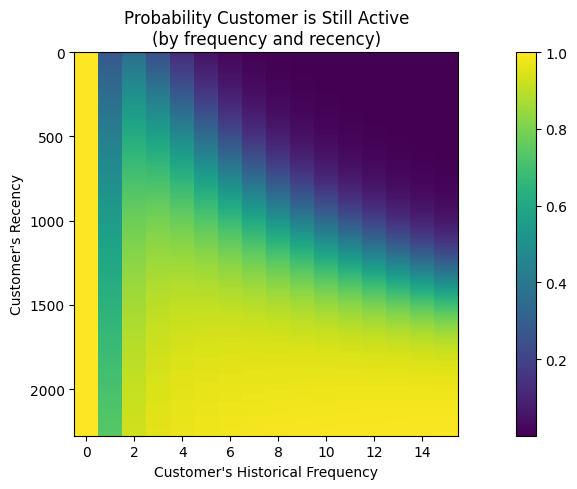

In [9]:
# P(alive) matrix
fig = plt.figure(figsize=(12, 5))
plot_probability_alive_matrix(bgf, max_frequency=15)
plt.title('Probability Customer is Still Active\n(by frequency and recency)')
plt.tight_layout()
plt.show()

In [10]:
# Compute per-customer predictions
df['p_alive'] = bgf.conditional_probability_alive(
    df['frequency'], df['recency'], df['T']
)
df['predicted_purchases_12m'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    CLV_DAYS, df['frequency'], df['recency'], df['T']
)

print("=== BG/NBD Predictions ===")
print(df[['p_alive', 'predicted_purchases_12m']].describe().round(4))

=== BG/NBD Predictions ===
          p_alive  predicted_purchases_12m
count  52507.0000               52507.0000
mean       0.9128                   0.2097
std        0.1511                   0.1109
min        0.2842                   0.0544
25%        0.8924                   0.1432
50%        1.0000                   0.1861
75%        1.0000                   0.2293
max        1.0000                   1.0565


## 3. Fit Gamma-Gamma Spend Model

The **Gamma-Gamma model** estimates average transaction value, conditional on being a repeat buyer.

**Key assumption:** Purchase frequency and monetary value are **independent** (correlation < 0.3 required).

In [11]:
# Gamma-Gamma requires repeat buyers only
repeat_buyers = df[df['frequency'] > 0].copy()
print(f"Repeat buyers for Gamma-Gamma fit: {len(repeat_buyers):,}")

# Verify independence assumption: |corr(frequency, monetary_value)| < 0.3
corr, pval = pearsonr(repeat_buyers['frequency'], repeat_buyers['monetary_value'])
print(f"\nPearson r(frequency, monetary_value) = {corr:.4f}  (p={pval:.4f})")
assert abs(corr) < 0.3, f"Correlation {corr:.3f} violates Gamma-Gamma independence assumption (must be < 0.3)"
print("✓ Frequency/monetary independence assumption satisfied")

Repeat buyers for Gamma-Gamma fit: 16,153

Pearson r(frequency, monetary_value) = -0.0037  (p=0.6380)
✓ Frequency/monetary independence assumption satisfied


In [12]:
# Fit Gamma-Gamma model
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(
    repeat_buyers['frequency'],
    repeat_buyers['monetary_value'],
)

print("=== Gamma-Gamma Model Summary ===")
print(ggf.summary)

=== Gamma-Gamma Model Summary ===
       coef  se(coef)  lower 95% bound  upper 95% bound
p  3.948520  0.037459         3.875100         4.021940
q  0.616029  0.005867         0.604531         0.627528
v  3.662684  0.037991         3.588221         3.737146


In [13]:
# Compute expected average spend per customer
# For repeat buyers: use Gamma-Gamma posterior estimate
# For one-time buyers (frequency=0): fallback to observed avg_order_value

gg_spend = ggf.conditional_expected_average_profit(
    repeat_buyers['frequency'],
    repeat_buyers['monetary_value'],
)

df['expected_avg_spend'] = df['avg_order_value']   # default: observed AOV
df.loc[df['frequency'] > 0, 'expected_avg_spend'] = gg_spend.values

print("=== Expected Average Spend ===")
print(df['expected_avg_spend'].describe().round(2))

=== Expected Average Spend ===
count    52507.00
mean        89.99
std         94.57
min          0.02
25%         32.00
50%         59.99
75%        114.46
max       1329.42
Name: expected_avg_spend, dtype: float64


## 4. Compute CLV

**CLV (12-month) = predicted_purchases_12m × expected_avg_spend**

This is undiscounted CLV for simplicity of stakeholder communication.

In [14]:
# Compute CLV
df['clv_12m'] = df['predicted_purchases_12m'] * df['expected_avg_spend']

print("=== 12-Month CLV Distribution ===")
print(df['clv_12m'].describe().round(2))

# Sanity check: one-time buyers should have lower CLV than repeat buyers
clv_onetime = df.loc[df['frequency'] == 0, 'clv_12m'].mean()
clv_repeat  = df.loc[df['frequency'] >= 1, 'clv_12m'].mean()
print(f"\nAvg CLV — one-time buyers: ${clv_onetime:.2f}")
print(f"Avg CLV — repeat buyers:   ${clv_repeat:.2f}")
assert clv_onetime < clv_repeat, "One-time buyers should have lower CLV than repeat buyers"
print("✓ Sanity check passed: one-time buyer CLV < repeat buyer CLV")

=== 12-Month CLV Distribution ===
count    52507.00
mean        19.01
std         22.87
min          0.00
25%          5.63
50%         11.43
75%         23.83
max        402.50
Name: clv_12m, dtype: float64

Avg CLV — one-time buyers: $14.59
Avg CLV — repeat buyers:   $28.94
✓ Sanity check passed: one-time buyer CLV < repeat buyer CLV


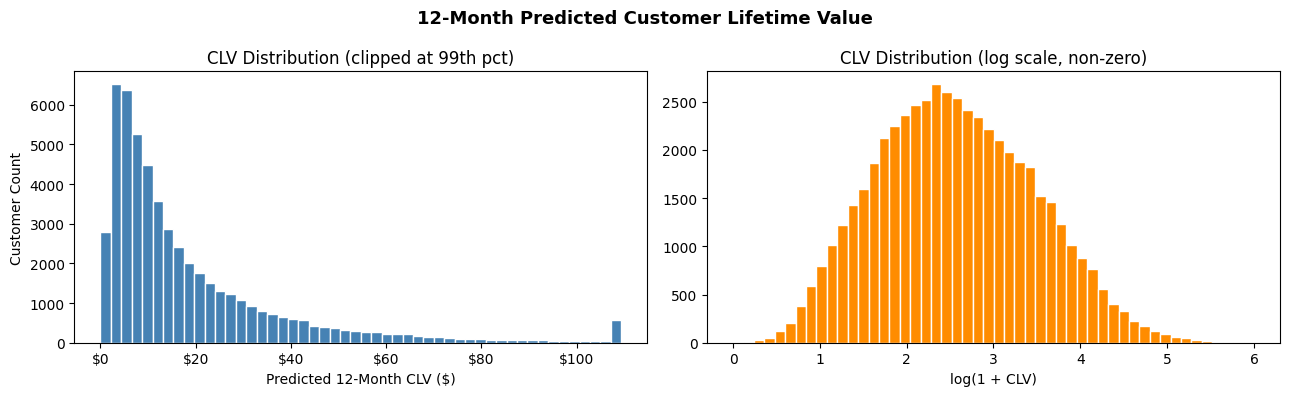

In [15]:
# CLV distribution (log scale)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Linear scale (clipped for clarity)
clv_clip = df['clv_12m'].clip(upper=df['clv_12m'].quantile(0.99))
axes[0].hist(clv_clip, bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Predicted 12-Month CLV ($)')
axes[0].set_ylabel('Customer Count')
axes[0].set_title('CLV Distribution (clipped at 99th pct)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Log scale (all customers)
clv_nonzero = df.loc[df['clv_12m'] > 0, 'clv_12m']
axes[1].hist(np.log1p(clv_nonzero), bins=50, color='darkorange', edgecolor='white')
axes[1].set_xlabel('log(1 + CLV)')
axes[1].set_title('CLV Distribution (log scale, non-zero)')

plt.suptitle('12-Month Predicted Customer Lifetime Value', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Top 20% customers → 55.9% of predicted CLV


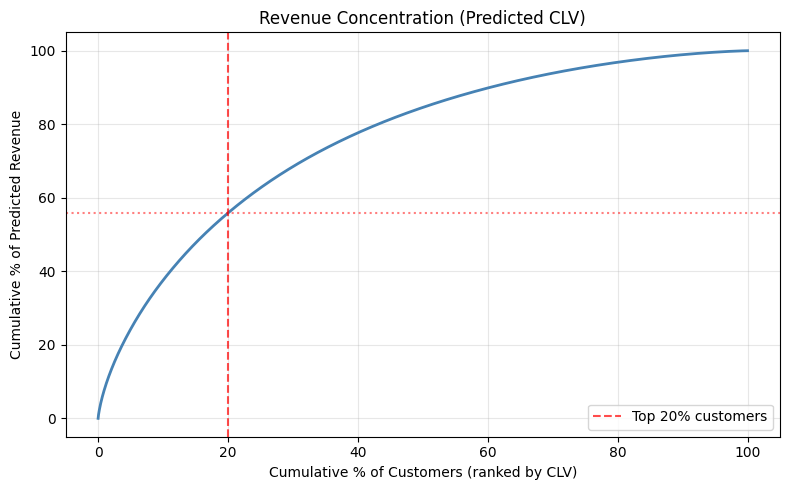

In [16]:
# Revenue concentration (Pareto check)
df_sorted = df.sort_values('clv_12m', ascending=False).reset_index(drop=True)
df_sorted['cumulative_clv_pct'] = df_sorted['clv_12m'].cumsum() / df_sorted['clv_12m'].sum()
df_sorted['customer_pct'] = (df_sorted.index + 1) / len(df_sorted)

top20_revenue = df_sorted.loc[df_sorted['customer_pct'] <= 0.20, 'clv_12m'].sum()
total_revenue = df_sorted['clv_12m'].sum()
print(f"Top 20% customers → {top20_revenue/total_revenue:.1%} of predicted CLV")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_sorted['customer_pct'] * 100, df_sorted['cumulative_clv_pct'] * 100,
        color='steelblue', linewidth=2)
ax.axvline(20, color='red', linestyle='--', alpha=0.7, label='Top 20% customers')
ax.axhline(df_sorted.loc[df_sorted['customer_pct'] <= 0.20, 'cumulative_clv_pct'].max() * 100,
           color='red', linestyle=':', alpha=0.5)
ax.set_xlabel('Cumulative % of Customers (ranked by CLV)')
ax.set_ylabel('Cumulative % of Predicted Revenue')
ax.set_title('Revenue Concentration (Predicted CLV)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Save Models and Scored Data

In [19]:
# Save BG/NBD and Gamma-Gamma models
os.makedirs('../models', exist_ok=True)
joblib.dump(bgf, BGNBD_PATH)
joblib.dump(ggf, GG_PATH)
print(f"✓ BG/NBD model saved to {BGNBD_PATH}")
print(f"✓ Gamma-Gamma model saved to {GG_PATH}")

PicklingError: Can't pickle local object <function BetaGeoFitter.fit.<locals>.<lambda> at 0x11cf359b0>

In [18]:
# Save scored customer data
os.makedirs('../data/processed', exist_ok=True)
df.to_csv(SCORED_PATH, index=False)
print(f"✓ CLV scored data saved to {SCORED_PATH}")
print(f"  Shape: {df.shape[0]:,} customers × {df.shape[1]} columns")
print(f"\nNew columns added:")
new_cols = ['p_alive', 'predicted_purchases_12m', 'expected_avg_spend', 'clv_12m']
print(df[new_cols].describe().round(4))

✓ CLV scored data saved to ../data/processed/clv_scored.csv
  Shape: 52,507 customers × 28 columns

New columns added:
          p_alive  predicted_purchases_12m  expected_avg_spend     clv_12m
count  52507.0000               52507.0000          52507.0000  52507.0000
mean       0.9128                   0.2097             89.9904     19.0066
std        0.1511                   0.1109             94.5664     22.8670
min        0.2842                   0.0544              0.0200      0.0017
25%        0.8924                   0.1432             32.0000      5.6318
50%        1.0000                   0.1861             59.9900     11.4276
75%        1.0000                   0.2293            114.4600     23.8256
max        1.0000                   1.0565           1329.4211    402.4987


---

**Next:** [03_clv_validation.ipynb](./03_clv_validation.ipynb) — Temporal holdout backtesting and lift curve validation